In [1]:
import warnings
warnings.filterwarnings("ignore")

In [2]:
import pandas as pd
import re
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import TfidfVectorizer

from collections import Counter

In [3]:
# загружаем ресурсы nltk
nltk.download('punkt') # токенизатор для разбиения текста на предложения и слова
nltk.download('wordnet') # лексическая база WordNet для лемматизации 
nltk.download('punkt_tab') # обновлённая версия punkt 
nltk.download('stopwords') # списки стоп-слов 

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\alexs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\alexs\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\alexs\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\alexs\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

## Загружаем данные

In [5]:
df = pd.read_csv("comments.csv")

In [6]:
arrayTxt = df["text"].to_list()

In [7]:
target = df["toxic"]

In [8]:
target.value_counts() # распределение таргета

toxic
0    143346
1     16225
Name: count, dtype: int64

In [10]:
df.isna().sum() # пропусков нет

text     0
toxic    0
dtype: int64

## 1. Почистить текст от символов, оставить только слова 

In [11]:
def clean_sent(sentence: str) -> str:
    """
        Устраняем мусор в тексте.
        Используем регулярку и замену
    """
    pattern_cls = r'[^a-zA-Zа-яА-ЯёЁ\s]'

    cls = re.compile(pattern_cls)

    sentence = re.sub(cls, "", sentence).strip().replace("\n", " ").replace("\xa0", "")
    return sentence

In [12]:
docSent = [] # массив комментариев без мусора

In [55]:
for sentence in arrayTxt:
    docSent.append(clean_sent(sentence))

In [56]:
len(docSent)

159571

In [13]:
docSentX = []

# устраняем коротки слова и слова, которые не являются словами(мусор, ссылки)
# убираем лишние пробелы между словами. В начале строки и в конце
for sentence in docSent:
    arr = sentence.split()
    for idx, elem in enumerate(arr):
        if len(elem) <= 1 or len(elem) > 30:
            del arr[idx]
    docSentX.append(" ".join(arr))

In [79]:
docSentX

['Explanation Why the edits made under my username Hardcore Metallica Fan were reverted They werent vandalisms just closure on some GAs after voted at New York Dolls FAC And please dont remove the template from the talk page since Im retired now',
 'Daww He matches this background colour Im seemingly stuck with Thanks talk January UTC',
 'Hey man Im really not trying to edit war Its just that this guy is constantly removing relevant information and talking to me through edits instead of my talk page He seems to care more about the formatting than the actual info',
 'More cant make any real suggestions on improvement wondered if the section statistics should be later on or subsection of types of accidents think the references may need tidying so that they are all in the exact same format ie date format etc can do that later on if noone else does first if you have any preferences for formatting style on references or want to do it yourself please let me know There appears to be backlog o

## 2-3. Пролемматизировать текст + Убрать стоп-слова

In [98]:
lemmatizer = WordNetLemmatizer()
STOP_WORDS = set(stopwords.words('english'))

lemmath_text = []

Используем стоп слова nltk

Леммантизируем текст, сразу удаляем стоп слова

In [99]:
for sentence in docSentX:
    tokens = word_tokenize(sentence.lower())
    lemmas = [lemmatizer.lemmatize(token) for token in tokens if token and token not in STOP_WORDS]

    lemmath_text.append(' '.join(lemmas))

In [100]:
lemmath_text

['explanation edits made username hardcore metallica fan reverted werent vandalism closure gas voted new york doll fac please dont remove template talk page since im retired',
 'daww match background colour im seemingly stuck thanks talk january utc',
 'hey man im really trying edit war guy constantly removing relevant information talking edits instead talk page seems care formatting actual info',
 'cant make real suggestion improvement wondered section statistic later subsection type accident think reference may need tidying exact format ie date format etc later noone else first preference formatting style reference want please let know appears backlog article review guess may delay reviewer turn listed relevant form eg',
 'sir hero chance remember page thats',
 'congratulation well use tool well talk',
 'cocksucker piss around work',
 'vandalism matt shirvington article reverted please dont banned',
 'sorry word nonsense offensive anyway im intending write anything articlewow would j

## 4. Вычислить TF-IDF для корпуса текстов, учитывая удаленные стоп-слова

In [164]:
vectorizer = TfidfVectorizer(
    max_features=5000,      # Топ-5000 слов
    min_df=2,              # Игнорировать редкие слова (<2 документов)
    max_df=0.95,           # Игнорировать слишком частые (>95%)
    ngram_range=(1, 2),    # Униграммы + биграммы
    lowercase=True
)

In [165]:
tfidf_matrix = vectorizer.fit_transform(lemmath_text)

In [166]:
feature_names = vectorizer.get_feature_names_out()

In [169]:
feature_names.shape

(5000,)

Вычислили tf-idf используя sklearn

## 5. Найти распределения топ-10 самых популярных слов и построить график

In [106]:
all_words = []

for elem in lemmath_text:
    all_words.extend(elem.split())

In [108]:
cooccurrence = Counter(all_words)

In [170]:
def visualize(counter: Counter, top_n: int = 10, title="Graphic"):
    top_words_list = counter.most_common(top_n)
    
    df_plot = pd.DataFrame(top_words_list, columns=['word', 'count'])
    
    plt.figure(figsize=(12, 8))
    sns.set_theme(style="whitegrid")
    
    sns.barplot(data=df_plot, y='word', x='count', palette='viridis')
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.xlabel('Частота встречаемости', fontsize=12)
    plt.ylabel('Слова', fontsize=12)
    plt.tight_layout()

    for i, v in enumerate(df_plot['count']):
        plt.text(v + 0.5, i, str(v), va='center', fontweight='bold')
    
    plt.show()

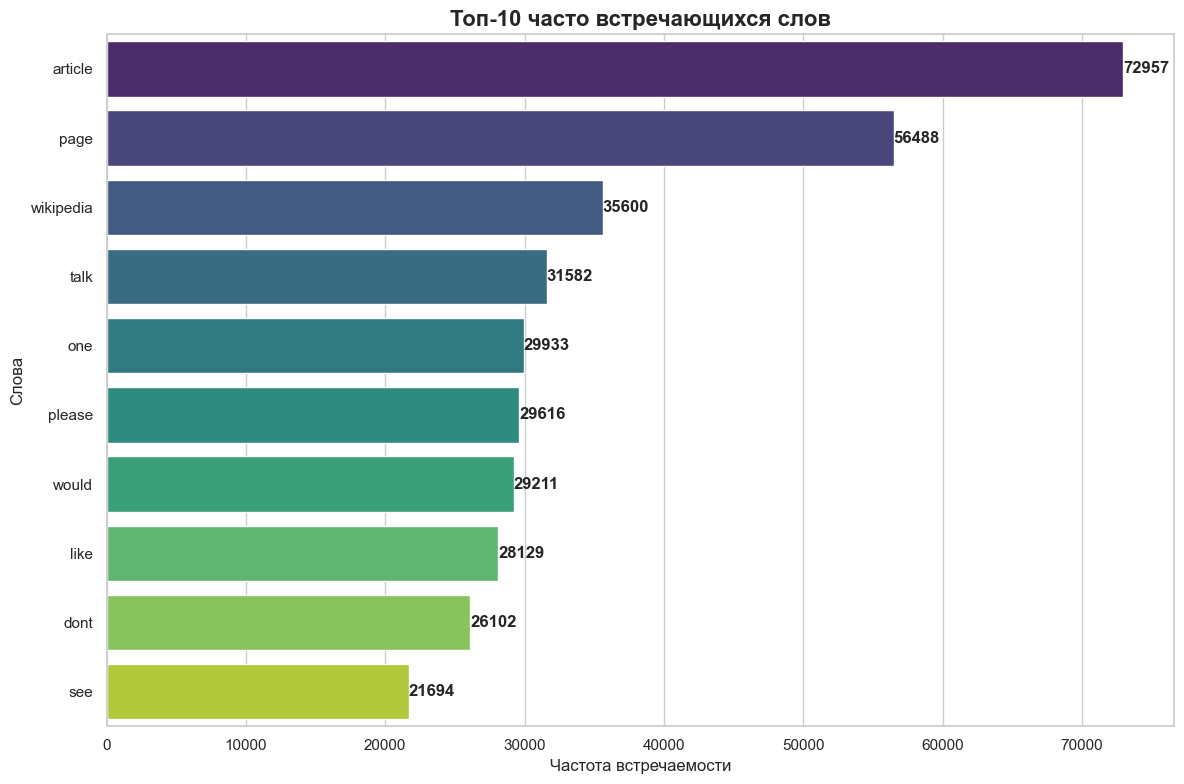

In [174]:
visualize(cooccurrence, 10, 'Топ-10 часто встречающихся слов')

## 6. Найти распределения топ-10 самых популярных слов среди положительных и отрицательных комментариев (0 - полож, 1 - отриц) и построить график

In [195]:
lemm_comments = pd.DataFrame({
    "comment": lemmath_text, 
    "toxic": target})

negative_comments = lemm_comments[lemm_comments["toxic"] == 1]["comment"].to_list()
positive_comments = lemm_comments[lemm_comments["toxic"] == 0]["comment"].to_list()

Забираем позитивные и отрицательные комментарии. В виде массива

In [201]:
dist_neg_words = []
dist_pos_words = []

for elem in negative_comments:
    for word in elem.split():
        dist_neg_words.append(word)

for elem in positive_comments:
    for word in elem.split():
        dist_pos_words.append(word)

Создаем массивы слов из корпусов комментариев по таргету.

In [157]:
negative_word = []
positive_word = []

analyzer = SentimentIntensityAnalyzer()

Используем модель vader для определения тональности слова

In [204]:
for wordPos in dist_pos_words:
    score_wrld = analyzer.polarity_scores(wordPos)

    if score_wrld["compound"] >= 0.05:
        positive_word.append(wordPos)

for wordNeg in dist_pos_words:
    score_wrld = analyzer.polarity_scores(wordNeg)

    if score_wrld["compound"] <= -0.05:
        negative_word.append(wordNeg)

In [160]:
cooccurrence_neg = Counter(negative_word)
cooccurrence_pos = Counter(positive_word)

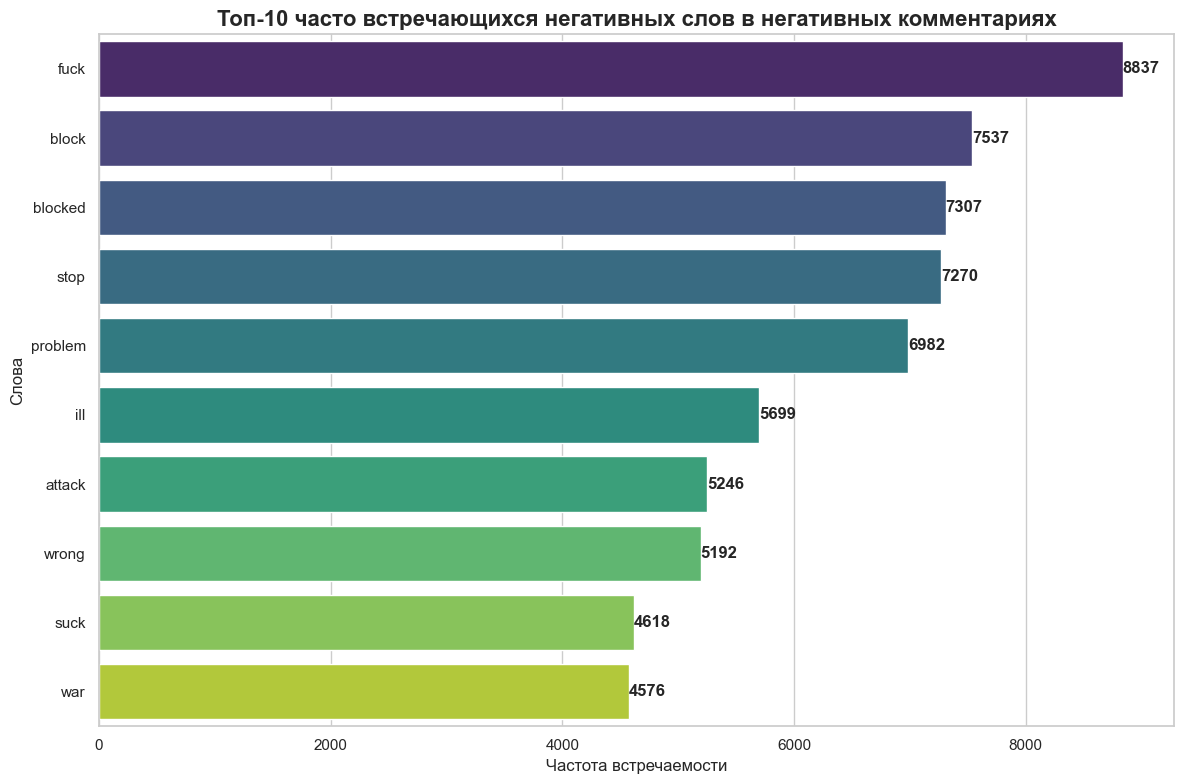

In [206]:
visualize(cooccurrence_neg, 10, 'Топ-10 часто встречающихся негативных слов в негативных комментариях')

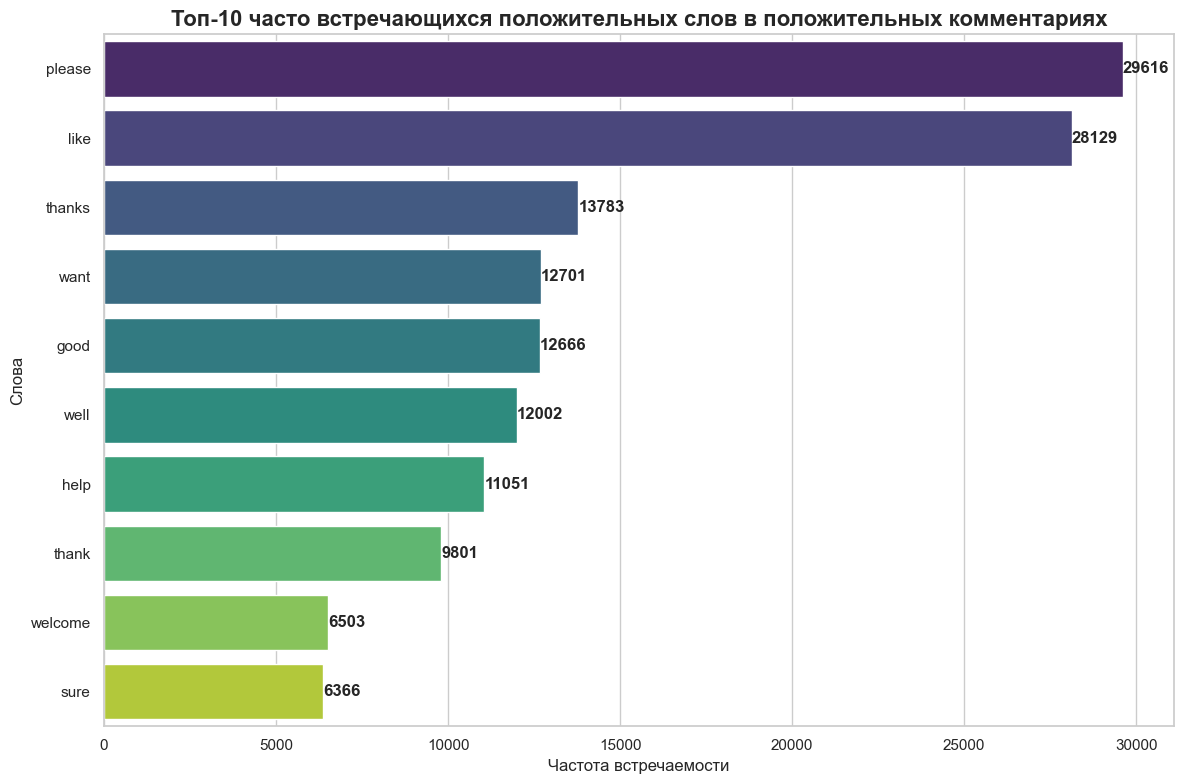

In [207]:
visualize(cooccurrence_pos, 10, 'Топ-10 часто встречающихся положительных слов в положительных комментариях')